# 1 Add Manual Review Columns
Add empty columns for manual coordinate review: Match_Comments, Manual_Match,
Manual_Lat, Manual_Long. Rows flagged by the distance reconciliation step can
be manually corrected here.

Input:  data/1_derived/5_geocode_truck_stops/2_cross_source_distances.csv
Output: data/1_derived/5_geocode_truck_stops/3_manual_review_ready.csv

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'source').exists() and (candidate / 'temp').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
IN_FILE  = PROJECT_ROOT / 'data' / '1_derived' / '5_geocode_truck_stops' / '2_cross_source_distances.csv'
OUT_DIR  = PROJECT_ROOT / 'data' / '1_derived' / '5_geocode_truck_stops'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FILE = OUT_DIR / '3_manual_review_ready.csv'

df = pd.read_csv(IN_FILE, low_memory=False)
print(f'Loaded {len(df):,} rows')

Loaded 38,135 rows


In [2]:
# Add manual review columns
df['Match_Comments'] = ''
df['Manual_Match'] = ''
df['Manual_Lat'] = ''
df['Manual_Long'] = ''

print('Added columns: Match_Comments, Manual_Match, Manual_Lat, Manual_Long')
print(f'Flagged rows available for review: {df["Flagged"].sum():,}')

Added columns: Match_Comments, Manual_Match, Manual_Lat, Manual_Long
Flagged rows available for review: 19,082


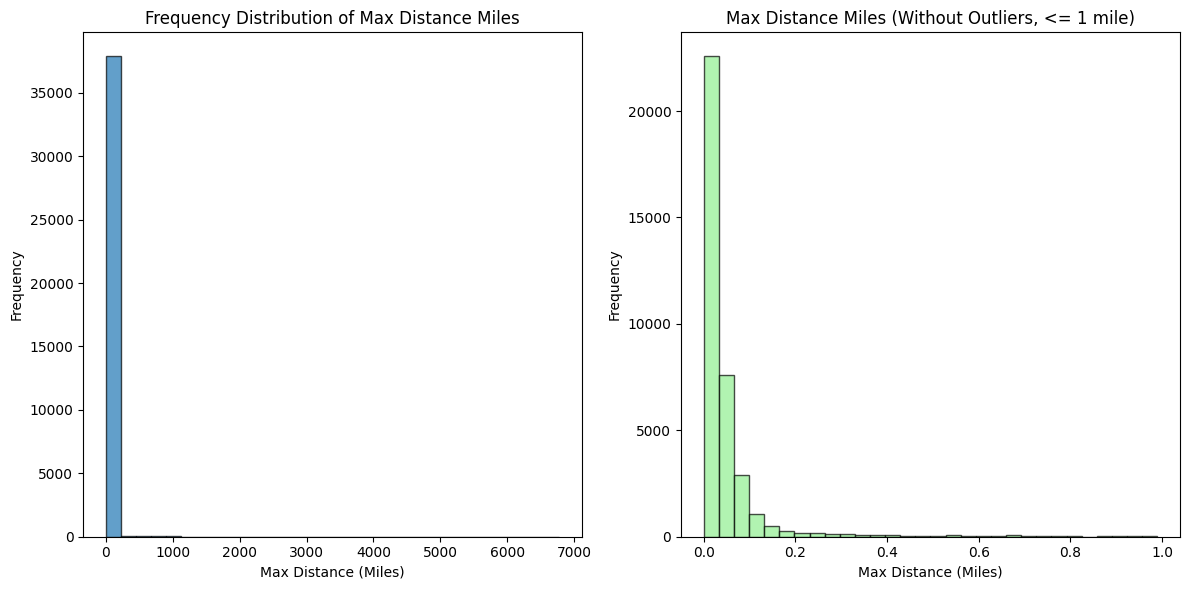

Statistics for max_distance_miles:
count    38135.000000
mean         6.926553
std        114.180786
min          0.000000
25%          0.000000
50%          0.019459
75%          0.056390
max       6781.932925
Name: max_distance_miles, dtype: float64


In [3]:
# Distance distribution overview (max_distance_miles)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].hist(df['max_distance_miles'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Frequency Distribution of Max Distance Miles')
axes[0].set_xlabel('Max Distance (Miles)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['max_distance_miles'] <= 1.0]['max_distance_miles'],
             bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title('Max Distance Miles (Without Outliers, <= 1 mile)')
axes[1].set_xlabel('Max Distance (Miles)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Statistics for max_distance_miles:')
print(df['max_distance_miles'].describe())

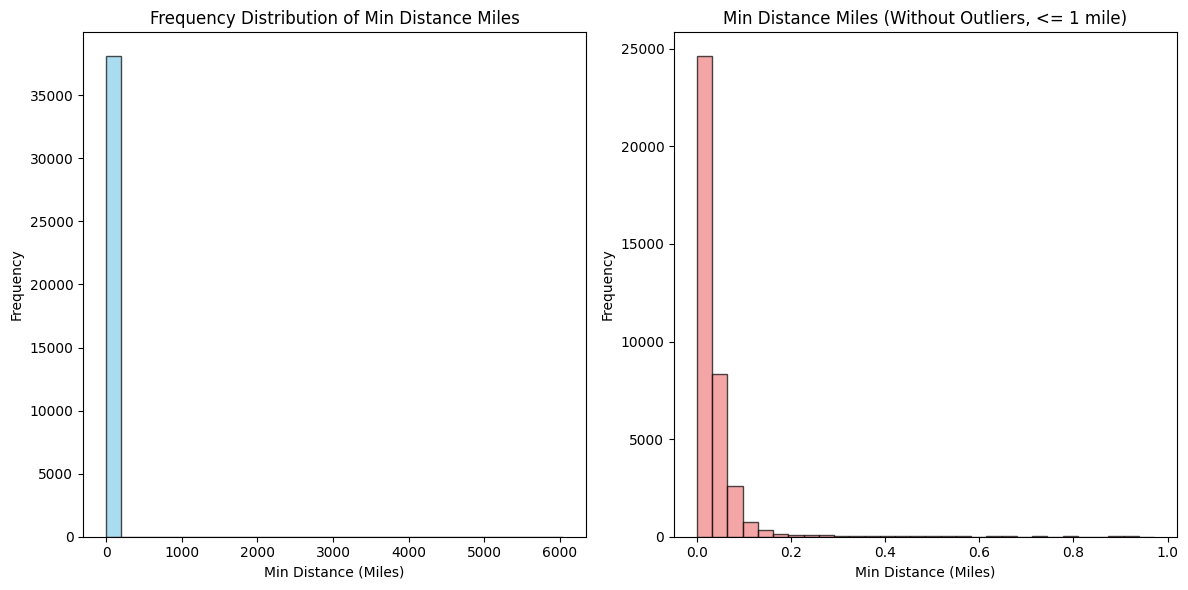

Statistics for min_distance_miles:
count    38135.000000
mean         2.134775
std         82.984655
min          0.000000
25%          0.000000
50%          0.014261
75%          0.044237
max       6041.251543
Name: min_distance_miles, dtype: float64


In [4]:
# Distance distribution overview (min_distance_miles)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].hist(df['min_distance_miles'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Frequency Distribution of Min Distance Miles')
axes[0].set_xlabel('Min Distance (Miles)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['min_distance_miles'] <= 1.0]['min_distance_miles'],
             bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_title('Min Distance Miles (Without Outliers, <= 1 mile)')
axes[1].set_xlabel('Min Distance (Miles)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Statistics for min_distance_miles:')
print(df['min_distance_miles'].describe())

C:\Users\Owner\AppData\Local\Temp\ipykernel_20836\1568973141.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([df['min_distance_miles'], df['max_distance_miles']],


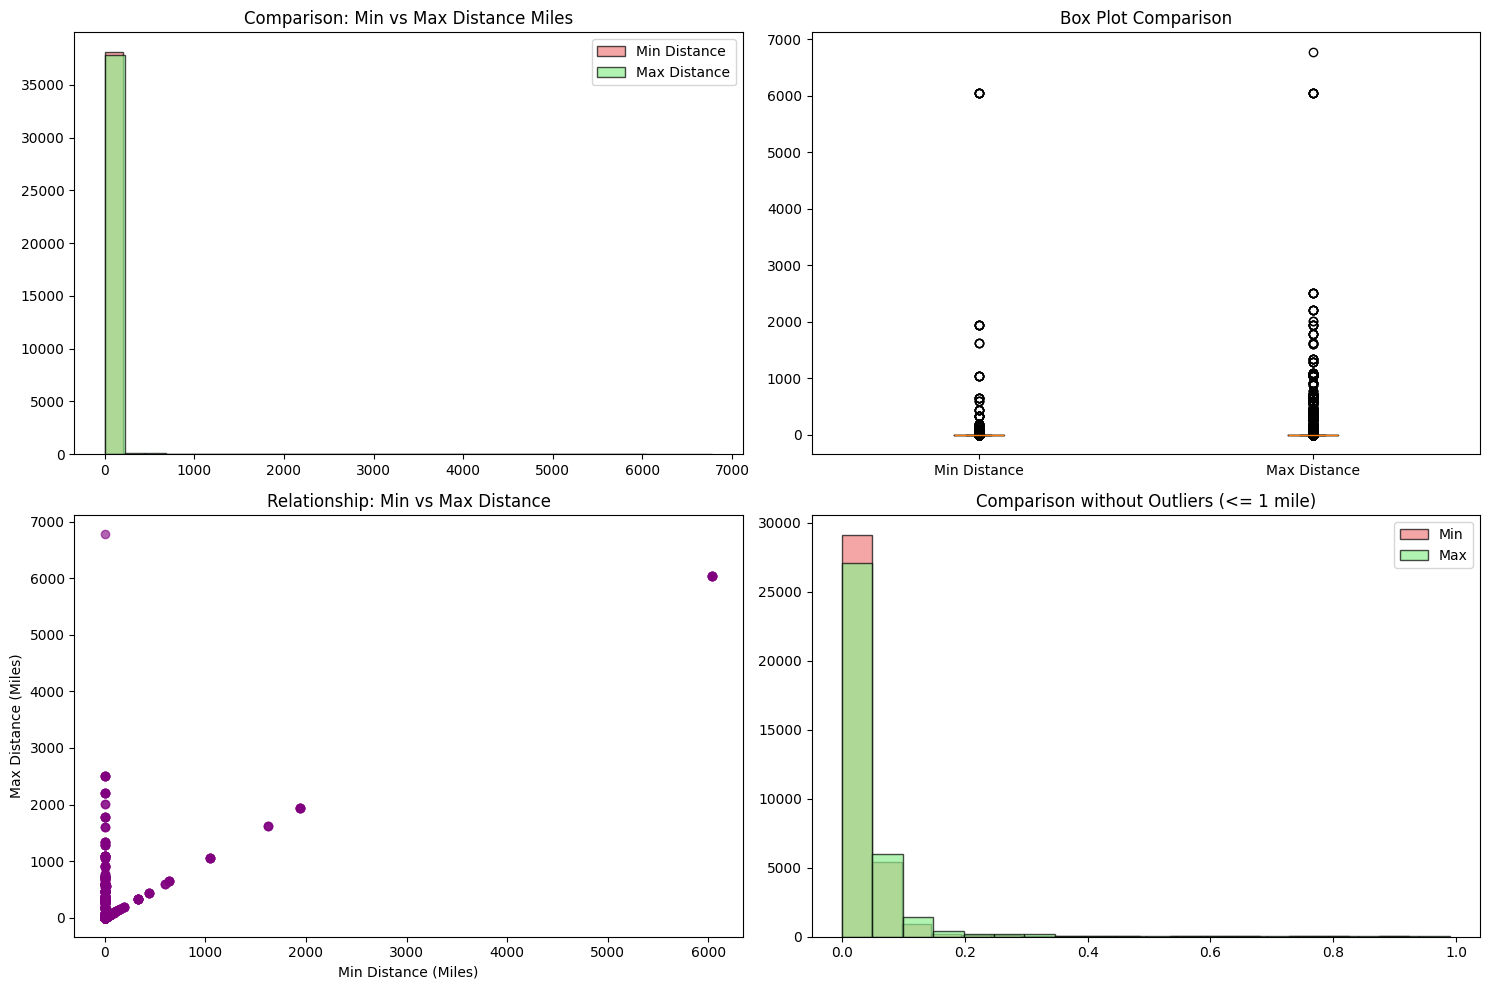

Correlation between min and max distances: 0.726


In [5]:
# Comparative analysis: min vs max distances
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df['min_distance_miles'], bins=30, alpha=0.7, label='Min Distance',
                color='lightcoral', edgecolor='black')
axes[0, 0].hist(df['max_distance_miles'], bins=30, alpha=0.7, label='Max Distance',
                color='lightgreen', edgecolor='black')
axes[0, 0].set_title('Comparison: Min vs Max Distance Miles')
axes[0, 0].legend()

axes[0, 1].boxplot([df['min_distance_miles'], df['max_distance_miles']],
                   labels=['Min Distance', 'Max Distance'])
axes[0, 1].set_title('Box Plot Comparison')

axes[1, 0].scatter(df['min_distance_miles'], df['max_distance_miles'],
                   alpha=0.6, color='purple')
axes[1, 0].set_xlabel('Min Distance (Miles)')
axes[1, 0].set_ylabel('Max Distance (Miles)')
axes[1, 0].set_title('Relationship: Min vs Max Distance')

both_ok = df[(df['min_distance_miles'] <= 1.0) & (df['max_distance_miles'] <= 1.0)]
axes[1, 1].hist(both_ok['min_distance_miles'], bins=20, alpha=0.7, label='Min',
                color='lightcoral', edgecolor='black')
axes[1, 1].hist(both_ok['max_distance_miles'], bins=20, alpha=0.7, label='Max',
                color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Comparison without Outliers (<= 1 mile)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f'Correlation between min and max distances: {df["min_distance_miles"].corr(df["max_distance_miles"]):.3f}')

In [6]:
# Save
df.to_csv(OUT_FILE, index=False)
print(f'Saved: {OUT_FILE}')
print(f'Shape: {df.shape}')

Saved: C:\Users\Owner\Desktop\Geocoding_Truck_Stops\data\1_derived\5_geocode_truck_stops\3_manual_review_ready.csv
Shape: (38135, 141)
